# APPLES 3

### IMPORT

In [5]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model 

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from screener import SCREENER

### DATA

In [6]:
months = [
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/eurnok_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eurnok_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_bid_{m}.parquet" for m in months]
]

### SPREAD

In [7]:
builder = SPREAD(threshold=1000) 
df = builder.build(my_files)

print(df.head(5))

built 17307 rows
                                    Asset_A    Asset_B     Log_A     Log_B  \
timestamp                                                                    
2025-01-02 10:08:24.604000+00:00  11.742865  11.434930  2.463246  2.436673   
2025-01-02 10:13:34.547000+00:00  11.746710  11.436620  2.463573  2.436820   
2025-01-02 10:17:20.398000+00:00  11.748715  11.443115  2.463744  2.437388   
2025-01-02 10:20:50.168000+00:00  11.744745  11.443115  2.463406  2.437388   
2025-01-02 10:24:06.749000+00:00  11.742145  11.441705  2.463185  2.437265   

                                  Return_A  Return_B  
timestamp                                             
2025-01-02 10:08:24.604000+00:00  0.000109  0.000074  
2025-01-02 10:13:34.547000+00:00  0.000327  0.000148  
2025-01-02 10:17:20.398000+00:00  0.000171  0.000568  
2025-01-02 10:20:50.168000+00:00 -0.000338  0.000000  
2025-01-02 10:24:06.749000+00:00 -0.000221 -0.000123  


### SCREENER

In [8]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report()

     COINTEGRATION SCREENER REPORT      
P-Value:    0.26698 -> fail (not cointegrated)
Half-Life:  833.52 Bars
----------------------------------------
Verdict: DO NOT TRADE. Spread is a random walk.



### ENGINE

In [9]:
df['Date'] = df.index.date
unique_days = df['Date'].unique()

train_days = 30 
print_freq = 10  # Set how often you want a daily update
out_of_sample_results = []
parameter_tracker = [] 

# The Walk-Forward Loop
for i in range(train_days, len(unique_days)):
    train_dates = unique_days[i - train_days : i]
    test_date = unique_days[i]
    
    train_df = df[df['Date'].isin(train_dates)].copy()
    test_df = df[df['Date'] == test_date].copy()
    
    # Fit Models
    engine = ENGINE(train_df)
    train_fitted = engine.fit_cointegration(z_window=250)
    engine.fit_ar_reversion(lags=1)
    engine.fit_garch_vol(scaling=10000)
    engine.fit_markov_regimes(k_regimes=2)
    
    # Predict Out-of-Sample
    oos_predictions = engine.predict_oos(test_df, engine.data, z_window=250)
    out_of_sample_results.append(oos_predictions)
    
    # Track the Daily Parameters
    parameter_tracker.append({
        'Date': test_date,
        'Beta': engine.beta,
        'Alpha': engine.alpha,
        'Safe_Variance': engine.safe_variance,
        'Danger_Variance': engine.danger_variance,
        'GARCH_Vol': engine.forecasted_vol,
        'AR_Phi': engine.ar_phi
    })

    # --- NEW: SMART PRINTOUTS ---
    # 1. Print when a new month rolls over
    if i > train_days and test_date.month != unique_days[i-1].month:
        print(f"\n📅 --- ENTERING {test_date.strftime('%B %Y').upper()} ---")
        
    # 2. Print periodic updates (Every N days)
    if i % print_freq == 0:
        print(f"[{test_date}] Beta: {engine.beta:>6.4f} | GARCH Vol: {engine.forecasted_vol:>5.2f} | AR_Phi: {engine.ar_phi:>6.4f}")

# Stitch data together
live_trading_data = pd.concat(out_of_sample_results)
df_params = pd.DataFrame(parameter_tracker).set_index('Date') 

print(f"\n🎉 OOS Dataset Built: {len(live_trading_data)} rows.")
print("📊 Parameter tracking complete.")

Cointegration Fitted | Beta: 0.5933 | Alpha: 1.0156
Markov Fitted | Danger Variance: 440.33 | Safe Variance: 6.51
[2025-02-13] Beta: 0.5933 | GARCH Vol:  4.20 | AR_Phi: 0.9874
Cointegration Fitted | Beta: 0.5082 | Alpha: 1.2232
Markov Fitted | Danger Variance: 525.83 | Safe Variance: 6.19
Cointegration Fitted | Beta: 0.4811 | Alpha: 1.2895
Markov Fitted | Danger Variance: 513.24 | Safe Variance: 6.00
Cointegration Fitted | Beta: 0.4699 | Alpha: 1.3168
Markov Fitted | Danger Variance: 525.84 | Safe Variance: 5.98
Cointegration Fitted | Beta: 0.4490 | Alpha: 1.3678
Markov Fitted | Danger Variance: 512.79 | Safe Variance: 5.88
Cointegration Fitted | Beta: 0.4568 | Alpha: 1.3491
Markov Fitted | Danger Variance: 464.98 | Safe Variance: 5.66
Cointegration Fitted | Beta: 0.4523 | Alpha: 1.3599
Markov Fitted | Danger Variance: 454.54 | Safe Variance: 5.44
Cointegration Fitted | Beta: 0.4367 | Alpha: 1.3980
Markov Fitted | Danger Variance: 493.83 | Safe Variance: 5.32
Cointegration Fitted | Bet

### BACKTESTER

In [10]:
import importlib
import backtester  

importlib.reload(backtester)
from backtester import BACKTESTER

bt = BACKTESTER(live_trading_data)

results_df = bt.run(
    base_z=1.25, 
    exit_z=0.0, 
    danger_threshold=1.1, 
    ar_limit=0.995, 
    fee_bps=0.5,
    stop_loss_bps=100.0,    
    take_profit_bps=25.0,   
    max_hold_bars=150       
)

### TEARSHEET


           INSTITUTIONAL PERFORMANCE REPORT            
Metric                    | Adaptive     | Static Base 
-------------------------------------------------------
Total Return (Bps)        | 906.97       | 878.15      
Annual Vol (Bps)          | 492.32       | 691.48      
Sharpe Ratio              | 2.03         | 1.40        
Sortino Ratio             | 1.58         | 1.35        
Max Drawdown (Bps)        | -272.06      | -587.60     
Calmar Ratio              | 3.33         | 1.49        
Win Rate                  | 49.46%       | 49.13%      
Profit Factor             | 1.09         | 1.05        



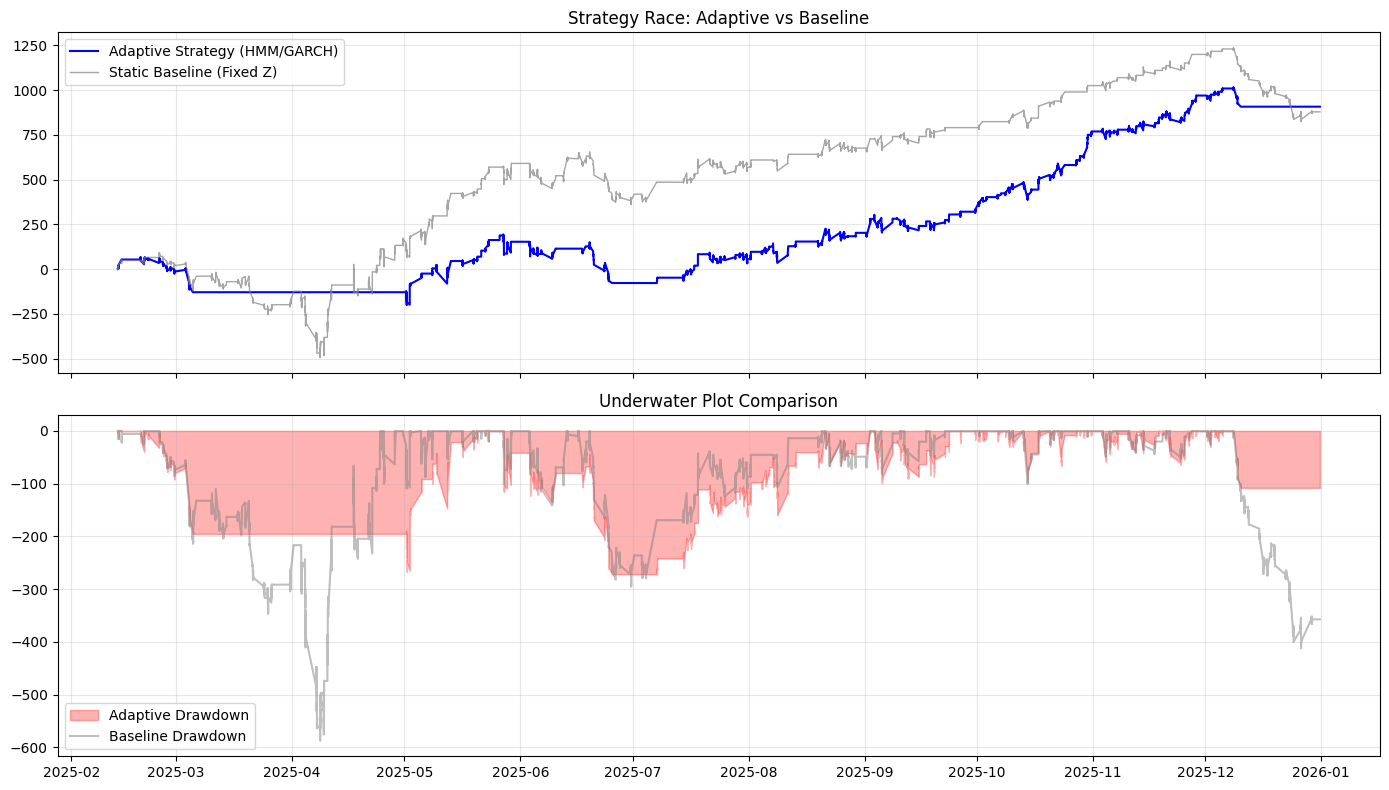

In [11]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_comparative_equity()